# VoxBind - Sample Metrics Dashboard

Summarises the cached `metrics.json` files written for every sampled pocket
under `voxbind/exps/<experiment>/samples/<run>/target_*/`.

### How to use
1. Run **section 0 (Setup)** once.
2. **Section 1** lists every experiment that has generated samples - review it.
3. In **section 2**, set `SELECTED` to an `idx` (or experiment name) from that list.
4. Run **sections 3-5** for the selected experiment; **section 6** compares all of them.

### Notes
- This dashboard only *reads* pre-computed `metrics.json` (it does not run
  RDKit or docking). Refresh those files with the Streamlit app
  (`notebook/webapp/app.py`).
- **Docking metrics (Vina) are optional.** They come from a separate evaluation
  step and may not be computed yet - targets without them show `NaN` in the
  `vina_*` columns and are flagged. Every other metric still prints normally.
- `status` column: `fresh` = metrics newer than `samples.sdf` -
  `stale` = out of date - `no-metrics` = not evaluated yet -
  `no-samples` = empty target directory.

In [1]:
# Section 0 - Setup: helper functions (run once).
import json
import math
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_rows", 300)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 260)
pd.set_option("display.max_colwidth", 100)


def show(obj, round_to=3):
    """Render a DataFrame/Series in Jupyter, falling back to plain text."""
    if isinstance(obj, (pd.DataFrame, pd.Series)):
        obj = obj.round(round_to)
    try:
        from IPython.display import display
        display(obj)
    except Exception:
        print(obj)


# -- locate the repository ---------------------------------------------------
def find_repo_root() -> Path:
    """Walk up from the working directory until voxbind/exps/ is found."""
    for cand in [Path.cwd(), *Path.cwd().parents]:
        if (cand / "voxbind" / "exps").is_dir():
            return cand
    fallback = Path("/home/shpark/prj-denovo/VoxBind")
    if (fallback / "voxbind" / "exps").is_dir():
        return fallback
    raise FileNotFoundError("Could not find voxbind/exps/ - run from inside the repo.")


REPO = find_repo_root()
EXPS_ROOT = REPO / "voxbind" / "exps"
METRICS_VERSION = 2          # version stamp written by notebook/webapp/metrics.py
print(f"repo      : {REPO}")
print(f"exps root : {EXPS_ROOT}")


# -- experiment / run / target discovery -------------------------------------
def list_runs(exp_dir: Path) -> list:
    """Sampling-run subdirs under <exp>/samples/ that hold target_* folders."""
    samples = exp_dir / "samples"
    if not samples.is_dir():
        return []
    return sorted(d.name for d in samples.iterdir()
                  if d.is_dir() and any(d.glob("target_*")))


def list_experiments() -> list:
    """Experiment names with at least one non-empty sampling run."""
    if not EXPS_ROOT.is_dir():
        return []
    return sorted(p.name for p in EXPS_ROOT.iterdir()
                  if p.is_dir() and list_runs(p))


def list_targets(exp_name: str, run: str) -> list:
    """Sorted target_* directories for one (experiment, run)."""
    run_dir = EXPS_ROOT / exp_name / "samples" / run
    if not run_dir.is_dir():
        return []
    return sorted(t for t in run_dir.glob("target_*") if t.is_dir())


# -- metrics.json loading and freshness --------------------------------------
def metrics_status(target_dir: Path) -> str:
    """One of: fresh | stale | no-metrics | no-samples."""
    mp = target_dir / "metrics.json"
    sdf = target_dir / "samples.sdf"
    if not sdf.exists():
        return "no-samples"
    if not mp.exists():
        return "no-metrics"
    try:
        data = json.loads(mp.read_text())
    except (json.JSONDecodeError, OSError):
        return "no-metrics"
    if data.get("version") != METRICS_VERSION:
        return "stale"
    return "fresh" if mp.stat().st_mtime >= sdf.stat().st_mtime else "stale"


def load_metrics(target_dir: Path):
    """Parsed metrics.json dict, or None if absent / unreadable."""
    mp = target_dir / "metrics.json"
    if not mp.exists():
        return None
    try:
        return json.loads(mp.read_text())
    except (json.JSONDecodeError, OSError):
        return None


# -- docking metrics (Vina) - optional, may not be computed yet --------------
# Per-sample docking is expected either as a nested {"vina": {...}} dict
# (poc_evaluate.py convention) or as flat vina_* keys. When nothing is found,
# the vina_* columns stay NaN and the dashboard flags the target/experiment.
VINA_COLS = ["vina_score", "vina_min", "vina_dock"]
_VINA_NESTED = {"score_only": "vina_score", "minimize": "vina_min", "dock": "vina_dock"}


def sample_docking(sample: dict) -> dict:
    """Extract {vina_score, vina_min, vina_dock} from one sample record."""
    out = {}
    v = sample.get("vina")
    if isinstance(v, dict) and "error" not in v:
        for src, dst in _VINA_NESTED.items():
            if isinstance(v.get(src), (int, float)):
                out[dst] = float(v[src])
    for col in VINA_COLS:
        if isinstance(sample.get(col), (int, float)):
            out[col] = float(sample[col])
    return out


def target_docking(metrics: dict) -> dict:
    """Mean Vina metrics for a target - NaN for any not computed."""
    out = {c: float("nan") for c in VINA_COLS}
    acc = {c: [] for c in VINA_COLS}
    for s in metrics.get("samples", []):
        for c, val in sample_docking(s).items():
            acc[c].append(val)
    for c in VINA_COLS:
        if acc[c]:
            out[c] = float(np.mean(acc[c]))
    # fall back to aggregate-level keys, in case a future pipeline writes them there
    agg = metrics.get("aggregates", {})
    aliases = {
        "vina_score": ("vina_score_mean", "vina_score", "Vina score mean"),
        "vina_min":   ("vina_min_mean", "vina_min", "Vina min mean"),
        "vina_dock":  ("vina_dock_mean", "vina_dock", "Vina dock mean"),
    }
    for c, names in aliases.items():
        if math.isnan(out[c]):
            for n in names:
                if isinstance(agg.get(n), (int, float)):
                    out[c] = float(agg[n])
                    break
    return out


def has_docking(metrics) -> bool:
    """True if any Vina metric is present in this target's metrics."""
    return metrics is not None and any(
        not math.isnan(v) for v in target_docking(metrics).values()
    )


def n_vina_failed(metrics) -> int:
    """Number of samples whose vina recorded an error (toolchain crash, worker
    fault, etc.). Distinguishes 'docking ran and failed on every sample' from
    'docking never ran' - both leave vina_* NaN, but the first is recoverable
    by re-running. Reads `aggregates.vina_n_failed` when present (written by
    metrics.py >= 2026-05-21); falls back to counting samples whose `vina`
    dict carries an `error` key for older caches."""
    if not metrics:
        return 0
    agg = metrics.get("aggregates", {})
    n = agg.get("vina_n_failed")
    if isinstance(n, int):
        return n
    return sum(1 for s in metrics.get("samples", [])
               if isinstance(s.get("vina"), dict) and "error" in s["vina"])


# -- table builders ----------------------------------------------------------
# `atoms` = per-target mean of sample n_atoms; needed for the paper-style
# comparison against VoxBind Table 1 (figures/voxbind_results.png).
PER_TARGET_COLS = [
    "target", "status", "computed_at", "n_total", "n_valid",
    "validity", "uniqueness", "diversity",
    "qed", "sa", "logp", "lipinski", "clash_free", "n_clashes", "atoms", "sim",
] + VINA_COLS + ["vina_n_failed", "high_affinity"]


def per_target_table(exp_name: str, run: str) -> pd.DataFrame:
    """One summary row per target_* directory of (experiment, run)."""
    rows = []
    for tdir in list_targets(exp_name, run):
        row = {"target": tdir.name, "status": metrics_status(tdir)}
        m = load_metrics(tdir)
        if m is not None:
            agg = m.get("aggregates", {})
            ca = m.get("computed_at", "") or ""
            row["computed_at"] = ca[:16].replace("T", " ")
            row["n_total"] = agg.get("n_total")
            row["n_valid"] = agg.get("n_valid")
            row["validity"] = agg.get("validity")
            row["uniqueness"] = agg.get("uniqueness")
            row["diversity"] = agg.get("diversity")
            row["qed"] = agg.get("qed_mean")
            row["sa"] = agg.get("sa_mean")
            row["logp"] = agg.get("logp_mean")
            row["lipinski"] = agg.get("lipinski_mean")
            row["high_affinity"] = agg.get("high_affinity")
            row["sim"] = agg.get("sim_to_ref_mean")
            row["vina_n_failed"] = n_vina_failed(m)
            samples = m.get("samples", [])
            if samples:
                row["clash_free"] = float(np.mean([
                    s.get("interactions", {}).get("n_clashes", 0) == 0
                    for s in samples
                ]))
                row["n_clashes"] = float(np.mean([
                    s.get("interactions", {}).get("n_clashes", 0)
                    for s in samples
                ]))
                atoms = [s.get("n_atoms") for s in samples
                         if isinstance(s.get("n_atoms"), (int, float))]
                if atoms:
                    row["atoms"] = float(np.mean(atoms))
            row.update(target_docking(m))
        rows.append(row)
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    for c in PER_TARGET_COLS:
        if c not in df.columns:
            df[c] = np.nan
    return df[PER_TARGET_COLS]


def experiment_aggregate(df: pd.DataFrame) -> dict:
    """Mean of the per-target table over targets (NaN where not computed).
    `vina_n_failed` is summed (not averaged) - it's a total sample-error count
    across the run, not a per-target rate."""
    numeric = ["validity", "uniqueness", "diversity", "qed", "sa", "logp",
               "lipinski", "clash_free", "n_clashes", "high_affinity", "sim"] + VINA_COLS
    out = {"n_targets": int(len(df))}
    out["evaluated"] = int((df["status"] == "fresh").sum()) if "status" in df else 0
    for c in numeric:
        out[c] = float(df[c].mean(skipna=True)) if (c in df and len(df)) else float("nan")
    out["vina_n_failed"] = (int(df["vina_n_failed"].fillna(0).sum())
                            if ("vina_n_failed" in df and len(df)) else 0)
    return out


def per_sample_table(exp_name: str, run: str, target_name: str) -> pd.DataFrame:
    """Every generated molecule for one target (empty if not evaluated).
    `vina_status` makes docking failures visible: OK = docked successfully,
    ERR = ran but crashed (full traceback summary in `vina_err`), — = never
    docked. Lets a reader distinguish 'NaN because docking errored' from
    'NaN because docking wasn't requested'."""
    tdir = EXPS_ROOT / exp_name / "samples" / run / target_name
    m = load_metrics(tdir)
    if m is None:
        return pd.DataFrame()
    rows = []
    for i, s in enumerate(m.get("samples", [])):
        ix = s.get("interactions", {})
        row = {
            "idx": i,
            "smiles": s.get("smiles", ""),
            "n_atoms": s.get("n_atoms"),
            "qed": s.get("qed"),
            "sa": s.get("sa"),
            "logp": s.get("logp"),
            "lipinski": s.get("lipinski"),
            "n_contacts": ix.get("n_contacts"),
            "n_clashes": ix.get("n_clashes"),
            "min_dist": ix.get("min_dist"),
            "sim_to_ref": s.get("sim_to_ref"),
        }
        for c in VINA_COLS:
            row[c] = np.nan
        v = s.get("vina")
        if isinstance(v, dict) and "error" in v:
            row["vina_status"] = "ERR"
            row["vina_err"] = v.get("error", "")
        elif isinstance(v, dict):
            row["vina_status"] = "OK"
            row["vina_err"] = ""
        else:
            row["vina_status"] = "—"
            row["vina_err"] = ""
        row.update(sample_docking(s))
        rows.append(row)
    return pd.DataFrame(rows)


def first_evaluated(exp_name: str):
    """Return (run, target_name) of the fresh-metrics target with most samples.

    Falls back to the first run/target if none have fresh metrics.
    """
    runs = list_runs(EXPS_ROOT / exp_name)
    best = None  # (n_valid, run, target_name)
    for run in runs:
        for t in list_targets(exp_name, run):
            if metrics_status(t) != "fresh":
                continue
            m = load_metrics(t) or {}
            n = m.get("aggregates", {}).get("n_valid", 0) or 0
            if best is None or n > best[0]:
                best = (n, run, t.name)
    if best is not None:
        return best[1], best[2]
    if runs:
        ts = list_targets(exp_name, runs[0])
        return runs[0], (ts[0].name if ts else None)
    return None, None


# -- paper-baseline comparison -----------------------------------------------
# Metrics shown in VoxBind Table 1 (figures/voxbind_results.png).
# (col_in_per_target_table, display label, lower_is_better).
# `atoms` has no ranking direction - reported for context.
PLOT_METRICS = [
    ("vina_score",    "Vina Score (↓)",       True),
    ("vina_min",      "Vina Min (↓)",         True),
    ("vina_dock",     "Vina Dock (↓)",        True),
    ("high_affinity", "High Affinity (%, ↑)", False),
    ("qed",           "QED (↑)",              False),
    ("sa",            "SA (↑)",               False),
    ("diversity",     "Diversity (↑)",        False),
    ("atoms",         "# atoms / mol.",       None),
]

# Hand-transcribed from figures/voxbind_results.png; (avg, med) per metric.
# `None` means the figure printed a dash. We only have summary stats for these
# baselines (no per-target breakdown), so std / per-target plots are not
# possible - the comparison and bar plot show Avg & Med only.
PAPER_BASELINES = {
    "Reference":     {"vina_score": (-6.36, -6.46), "vina_min": (-6.71, -6.49),
                      "vina_dock":  (-7.45, -7.26), "high_affinity": (None, None),
                      "qed": (0.48, 0.47),          "sa":  (0.73, 0.74),
                      "diversity": (None, None),    "atoms": (22.8, 21.5)},
    "AR":            {"vina_score": (-5.75, -5.64), "vina_min": (-6.18, -5.88),
                      "vina_dock":  (-6.75, -6.62), "high_affinity": (37.9, 31.0),
                      "qed": (0.51, 0.50),          "sa":  (0.63, 0.63),
                      "diversity": (0.70, 0.70),    "atoms": (17.6, 16.0)},
    "Pocket2Mol":    {"vina_score": (-5.14, -4.70), "vina_min": (-6.42, -5.82),
                      "vina_dock":  (-7.15, -6.79), "high_affinity": (48.4, 51.0),
                      "qed": (0.56, 0.57),          "sa":  (0.74, 0.75),
                      "diversity": (0.69, 0.71),    "atoms": (17.7, 15.0)},
    "DiffSBDD":   {"vina_score": (-1.94, -4.24), "vina_min": (-5.85, -5.94),
                      "vina_dock":  (-7.00, -6.90), "high_affinity": (46.3, 47.2),
                      "qed": (0.48, 0.48),          "sa":  (0.58, 0.57),
                      "diversity": (0.73, 0.72),    "atoms": (24.0, 23.0)},
    "TargetDiff":    {"vina_score": (-5.47, -6.23), "vina_min": (-6.64, -6.83),
                      "vina_dock":  (-7.80, -7.91), "high_affinity": (58.1, 59.1),
                      "qed": (0.48, 0.48),          "sa":  (0.58, 0.58),
                      "diversity": (0.72, 0.71),    "atoms": (24.2, 24.0)},
    "DecompDiff":    {"vina_score": (-5.67, -6.04), "vina_min": (-7.04, -7.09),
                      "vina_dock":  (-8.39, -8.43), "high_affinity": (64.4, 71.0),
                      "qed": (0.45, 0.43),          "sa":  (0.61, 0.60),
                      "diversity": (0.68, 0.68),    "atoms": (20.9, 21.0)},
    "VoxBind 0.9": {"vina_score": (-6.94, -7.11), "vina_min": (-7.54, -7.55),
                      "vina_dock":  (-8.30, -8.41), "high_affinity": (71.3, 71.5),
                      "qed": (0.57, 0.58),          "sa":  (0.70, 0.69),
                      "diversity": (0.73, 0.74),    "atoms": (23.4, 24.0)},
    "VoxBind 1.0": {"vina_score": (-6.63, -6.70),  "vina_min": (-7.12, -7.18),
                      "vina_dock":  (-7.82, -7.89),   "high_affinity": (58.3, 61.5),
                      "qed": (0.55, 0.57),          "sa":  (0.69, 0.69),
                      "diversity": (0.75, 0.76),    "atoms": (21.7, 22.0)},
}


# Per-metric scale factor applied to *our* values so they line up with the
# paper's reporting units. high_affinity in metrics.json is a fraction (0-1);
# the paper reports percent (0-100).
_PAPER_SCALE = {"high_affinity": 100.0}


def experiment_aggregate_avg_med(df) -> dict:
    """Like experiment_aggregate but returns {metric}_avg + {metric}_med over
    targets - matches the Avg|Med presentation in PAPER_BASELINES so the two
    sources of rows share one schema. Applies _PAPER_SCALE to put our values
    in the same units as the paper figure."""
    out = {"n_targets": int(len(df)),
           "evaluated": int((df["status"] == "fresh").sum()) if "status" in df else 0}
    for metric, _, _ in PLOT_METRICS:
        scale = _PAPER_SCALE.get(metric, 1.0)
        if metric in df and len(df):
            out[f"{metric}_avg"] = float(df[metric].mean(skipna=True)) * scale
            out[f"{metric}_med"] = float(df[metric].median(skipna=True)) * scale
        else:
            out[f"{metric}_avg"] = float("nan")
            out[f"{metric}_med"] = float("nan")
    return out


def paper_baseline_rows() -> list:
    """PAPER_BASELINES → comparison-table rows (run='paper'). Mirrors the
    schema of experiment_aggregate_avg_med so the two row sources can be
    concatenated into one DataFrame."""
    rows = []
    for name, vals in PAPER_BASELINES.items():
        row = {"experiment": name, "run": "paper"}
        for metric, _, _ in PLOT_METRICS:
            avg, med = vals.get(metric, (None, None))
            row[f"{metric}_avg"] = float("nan") if avg is None else float(avg)
            row[f"{metric}_med"] = float("nan") if med is None else float(med)
        rows.append(row)
    return rows


print("helpers ready: list_experiments, list_runs, list_targets,")
print("               per_target_table, experiment_aggregate, per_sample_table,")
print("               n_vina_failed (sample-error count per target)")
print("paper-style helpers: experiment_aggregate_avg_med, paper_baseline_rows,")
print("                     PAPER_BASELINES, PLOT_METRICS")

repo      : /home/shpark/prj-denovo/VoxBind
exps root : /home/shpark/prj-denovo/VoxBind/voxbind/exps
helpers ready: list_experiments, list_runs, list_targets,
               per_target_table, experiment_aggregate, per_sample_table,
               n_vina_failed (sample-error count per target)
paper-style helpers: experiment_aggregate_avg_med, paper_baseline_rows,
                     PAPER_BASELINES, PLOT_METRICS


## Experiment list

`EXPS` is hard-coded to the runs we report against the VoxBind paper
baselines (figure `figures/voxbind_results.png`):

- `260519_voxbind_10k_density_aligned`
- `260523_voxbind_10k_density_vit_mae_frozen`
- `260525_voxbind_10k_density_vit_electra_frozen`
- `reproduction`

Edit the `EXPS = [...]` list in the next cell to track different experiments.
To restore the auto-discovery behaviour, replace it with `EXPS = list_experiments()`.

The `metrics` / `docking` columns are coverage counts (`computed / total`).

In [2]:
# Section 1 - hand-picked experiments for the paper-style comparison.
# Auto-discovery (list_experiments()) is intentionally bypassed - this
# dashboard tracks three runs against the VoxBind paper baselines.
EXPS = [
    "260519_voxbind_10k_density_aligned",
    "260523_voxbind_10k_density_vit_mae_frozen",
    "260525_voxbind_10k_density_vit_electra_frozen",
    "reproduction",
]

overview = []
for i, exp_name in enumerate(EXPS):
    runs = list_runs(EXPS_ROOT / exp_name)
    n_targets = n_fresh = n_dock = n_failed = 0
    for run in runs:
        for tdir in list_targets(exp_name, run):
            n_targets += 1
            m = load_metrics(tdir)
            if metrics_status(tdir) == "fresh":
                n_fresh += 1
            if has_docking(m):
                n_dock += 1
            n_failed += n_vina_failed(m)
    # docking column: target-level coverage + (if any) sample-level error count.
    # Distinguishes 'never computed' from 'computed but every dock crashed'.
    if n_dock:
        dock_str = f"{n_dock}/{n_targets}"
    elif n_failed:
        dock_str = f"0/{n_targets}"
    else:
        dock_str = "not computed"
    if n_failed:
        dock_str += f"  ·  {n_failed} errored"
    overview.append({
        "idx": i,
        "experiment": exp_name,
        "runs": ", ".join(runs),
        "targets": n_targets,
        "metrics": f"{n_fresh}/{n_targets}",
        "docking": dock_str,
    })

if not EXPS:
    print(f"No experiments selected - edit the EXPS list above.")
else:
    print(f"{len(EXPS)} experiment(s) tracked:")
    show(pd.DataFrame(overview).set_index("idx"))


# Section 6 - compare every experiment in EXPS.
def target_reference(metrics):
    """Reference-ligand metrics for one target, or {} when absent.

    Read from the target's metrics.json `reference` key (qed/sa/logp/lipinski
    and the Vina scores). validity/uniqueness/diversity/clash_free are not
    defined for a single ligand.
    """
    ref = (metrics or {}).get("reference")
    if not isinstance(ref, dict) or "error" in ref:
        return {}
    out = {}
    for k in ("qed", "sa", "logp", "lipinski"):
        if isinstance(ref.get(k), (int, float)):
            out[k] = float(ref[k])
    v = ref.get("vina")
    if isinstance(v, dict) and "error" not in v:
        for src, dst in _VINA_NESTED.items():
            if isinstance(v.get(src), (int, float)):
                out[dst] = float(v[src])
    return out


def experiment_reference_row(exp_name):
    """Mean reference-ligand metrics over every target of an experiment.

    Gathered from each target's metrics.json - there is no `reference/` run on
    disk. Returned with the same keys as experiment_aggregate(); the set-level
    columns (validity/uniqueness/diversity/clash_free) stay NaN.
    """
    refs = []
    for run in list_runs(EXPS_ROOT / exp_name):
        for tdir in list_targets(exp_name, run):
            r = target_reference(load_metrics(tdir))
            if r:
                refs.append(r)
    metric_cols = ["qed", "sa", "logp", "lipinski"] + VINA_COLS
    row = {c: float("nan") for c in
           ["validity", "uniqueness", "diversity", "clash_free", "n_clashes"] + metric_cols}
    row["n_targets"] = row["evaluated"] = len(refs)
    for c in metric_cols:
        vals = [r[c] for r in refs if c in r]
        if vals:
            row[c] = float(np.mean(vals))
    return row


def _highlight_best(df):
    """Comparison-table CSS: underline the best run within each experiment,
    bold the best across all experiments. Higher is better, except the
    lower-is-better Vina columns; logp and the count columns are not ranked.
    The 'reference' rows are a baseline and are excluded from the ranking.
    """
    higher = ["validity", "uniqueness", "diversity", "qed", "sa",
              "lipinski", "clash_free", "n_clashes", "high_affinity"]
    lower = ["vina_score", "vina_min", "vina_dock"]
    css = pd.DataFrame("", index=df.index, columns=df.columns)
    experiments = df.index.get_level_values("experiment")
    not_ref = pd.Series(df.index.get_level_values("run") != "reference",
                        index=df.index)
    for col in higher + lower:
        if col not in df.columns:
            continue
        series = df[col].where(not_ref)
        is_max = col in higher
        best = series.max() if is_max else series.min()
        if pd.notna(best):
            css.loc[series == best, col] += "font-weight: bold;"
        for exp in experiments.unique():
            grp = series[experiments == exp].dropna()
            if grp.empty:
                continue
            ebest = grp.max() if is_max else grp.min()
            in_exp = pd.Series(experiments == exp, index=df.index)
            css.loc[in_exp & (series == ebest), col] += "text-decoration: underline;"
    return css


def _color_vs_reference(df):
    """Comparison-table CSS: shade every non-reference run by how its metric
    compares with the reference ligand of the *same* experiment - light green
    when the run beats the reference, light red when it is worse. Columns with
    no reference value (validity/uniqueness/diversity/clash_free) or no defined
    direction (logp, the count columns) are left uncoloured.
    """
    higher = ["qed", "sa", "lipinski"]               # higher is better
    lower = ["vina_score", "vina_min", "vina_dock"]  # lower is better
    green = "background-color: #d8f0d8;"
    red = "background-color: #f5d8d8;"
    css = pd.DataFrame("", index=df.index, columns=df.columns)
    experiments = df.index.get_level_values("experiment")
    runs = df.index.get_level_values("run")
    for exp in experiments.unique():
        ref_rows = df[(experiments == exp) & (runs == "reference")]
        if ref_rows.empty:
            continue
        ref = ref_rows.iloc[0]
        run_idx = df.index[(experiments == exp) & (runs != "reference")]
        for col in higher + lower:
            if col not in df.columns or pd.isna(ref[col]):
                continue
            better_when_higher = col in higher
            for idx in run_idx:
                val = df.at[idx, col]
                if pd.isna(val):
                    continue
                better = val > ref[col] if better_when_higher else val < ref[col]
                css.at[idx, col] = green if better else red
    return css


def _separator_table_styles(df):
    """Return set_table_styles entries drawing a thick black border above the
    first row of each experiment block (after the first one). With a MultiIndex,
    the 'experiment' th uses rowspan and only exists on the *first* row of its
    block - putting border-top there guarantees the line spans from the very
    first column (experiment) across the entire row.
    """
    experiments = df.index.get_level_values("experiment")
    styles = []
    for i in range(1, len(df)):
        if experiments[i] != experiments[i - 1]:
            # nth-child is 1-based; selector matches both th (index) and td cells
            styles.append({
                "selector": (f"tbody tr:nth-child({i + 1}) th, "
                             f"tbody tr:nth-child({i + 1}) td"),
                "props": "border-top: 2px solid black;",
            })
    return styles


cmp_rows = []
for exp_name in EXPS:
    for run in list_runs(EXPS_ROOT / exp_name):
        df = per_target_table(exp_name, run)
        if df.empty:
            continue
        cmp_rows.append({"experiment": exp_name, "run": run,
                         **experiment_aggregate(df)})
    # gather the reference ligands into a virtual 'reference' run (no folder)
    ref_row = experiment_reference_row(exp_name)
    if ref_row["n_targets"]:
        cmp_rows.append({"experiment": exp_name, "run": "reference", **ref_row})

cmp_df = pd.DataFrame(cmp_rows)
if cmp_df.empty:
    print("Nothing to compare - no experiments with samples.")
else:
    _cmp = cmp_df.set_index(["experiment", "run"])
    _styled = (_cmp.style
               .apply(_highlight_best, axis=None)
               .apply(_color_vs_reference, axis=None)
               .set_table_styles(_separator_table_styles(_cmp), overwrite=False)
               .format(precision=3, na_rep="NaN"))
    show(_styled)
    print("  underline = best within an experiment  ·  bold = best across all")
    print("  green / red cell = run metric better / worse than its reference ligand")
    print("  'reference' run = mean reference-ligand metrics (baseline, not ranked)")
    missing = [c for c in VINA_COLS if cmp_df[c].isna().all()]
    if missing:
        print(f"  docking not computed anywhere - NaN columns: {', '.join(missing)}")
    n_err_total = int(cmp_df["vina_n_failed"].fillna(0).sum()) if "vina_n_failed" in cmp_df else 0
    if n_err_total:
        print(f"  vina_n_failed column = total sample-level dock errors per (experiment, run); {n_err_total} across all runs")

4 experiment(s) tracked:


,experiment,runs,targets,metrics,docking
idx,,,,,
0,260519_voxbind_10k_density_aligned,"res_test_n10, res_test_n10_ep138",58,58/58,57/58
1,260523_voxbind_10k_density_vit_mae_frozen,"res_ep379_10pockets, res_ep379_fulltest",89,89/89,89/89
2,260525_voxbind_10k_density_vit_electra_frozen,res_electra_fulltest,79,79/79,79/79
3,reproduction,"res, res_repro_10pockets, res_repro_fulltest",120,120/120,120/120


  underline = best within an experiment  ·  bold = best across all
  green / red cell = run metric better / worse than its reference ligand
  'reference' run = mean reference-ligand metrics (baseline, not ranked)


## Paper-style comparison

Lines up our three experiments against the VoxBind paper baselines from
`figures/voxbind_results.png` (Pinheiro et al., Table 1 on CrossDocked2020).

Each metric column is split into **Avg** and **Med** to match the paper.
- Our rows: Avg = mean over targets, Med = median over targets.
- Baseline rows (`run = paper`): values transcribed by hand from the figure;
  `—` is shown where the paper printed a dash (no value reported).

`# atoms / mol.` is added for context and is **not** ranked - no defined
better-direction. `vina_min` direction inferred from the paper's ↓ arrow.

In [3]:
# Section 6b - Paper-style comparison with Avg | Med columns.
# Baselines come from PAPER_BASELINES (hand-transcribed); ours from
# experiment_aggregate_avg_med over per_target_table.

paper_rows = paper_baseline_rows()
ours_rows = []
for exp_name in EXPS:
    for run in list_runs(EXPS_ROOT / exp_name):
        df = per_target_table(exp_name, run)
        if df.empty:
            continue
        ours_rows.append({"experiment": exp_name, "run": run,
                          **experiment_aggregate_avg_med(df)})

paper_cmp = pd.DataFrame(paper_rows + ours_rows)
if paper_cmp.empty:
    print("Nothing to compare - no experiments with samples.")
else:
    # Build MultiIndex columns: (display label, Avg|Med) for each PLOT_METRICS entry.
    flat_cols = []
    multi_cols = []
    for metric, label, _ in PLOT_METRICS:
        for agg in ("avg", "med"):
            flat_cols.append(f"{metric}_{agg}")
            multi_cols.append((label, agg.title()))
    paper_cmp = paper_cmp.set_index(["experiment", "run"])[flat_cols]
    paper_cmp.columns = pd.MultiIndex.from_tuples(multi_cols,
                                                  names=["metric", "agg"])

    # label → lower_is_better lookup; None means "no direction" (don't rank).
    _direction = {label: lb for _, label, lb in PLOT_METRICS}

    def _hl_best_paper(df):
        """Bold the best Avg|Med value across all rows (baselines + ours) per
        column. Skip 'atoms' since it has no ranking direction."""
        css = pd.DataFrame("", index=df.index, columns=df.columns)
        for col in df.columns:
            label, _agg = col
            lb = _direction.get(label)
            if lb is None:
                continue
            s = df[col]
            best = s.min() if lb else s.max()
            if pd.notna(best):
                css.loc[s == best, col] = "font-weight: bold;"
        return css

    def _hl_paper_rows(df):
        """Tint the paper-baseline block (run=='paper') light gray so the
        eye separates 'reported in paper' from 'our runs'."""
        gray = "background-color: #f0f0f0;"
        css = pd.DataFrame("", index=df.index, columns=df.columns)
        is_paper = df.index.get_level_values("run") == "paper"
        css.loc[is_paper, :] = gray
        return css

    def _border_above_ours(df):
        """Thick black border above the first non-paper row to visually
        separate the paper-baseline block from our runs."""
        runs = df.index.get_level_values("run")
        styles = []
        for i in range(1, len(df)):
            # transition from paper → not-paper
            if runs[i] != "paper" and runs[i - 1] == "paper":
                styles.append({
                    "selector": (f"tbody tr:nth-child({i + 1}) th, "
                                 f"tbody tr:nth-child({i + 1}) td"),
                    "props": "border-top: 2px solid black;",
                })
        return styles

    styled = (paper_cmp.style
              .apply(_hl_paper_rows, axis=None)
              .apply(_hl_best_paper, axis=None)
              .set_table_styles(_border_above_ours(paper_cmp), overwrite=False)
              .format(precision=3, na_rep="—"))
    show(styled)
    print("  gray rows  = paper baselines (figures/voxbind_results.png)")
    print("  bold value = best across all rows for that Avg / Med column (atoms not ranked)")
    print("  '—'        = value not reported / not computed")

  gray rows  = paper baselines (figures/voxbind_results.png)
  bold value = best across all rows for that Avg / Med column (atoms not ranked)
  '—'        = value not reported / not computed


### Visual comparison — bar plot

One subplot per metric. Bar height = **Avg**, red tick = **Med**.
- Light-gray bars: paper baselines (transcribed from `voxbind_results.png`).
- Colored bars: our three experiments (one color per experiment, separate bar per run).
- Vina-* metrics keep their natural (negative) scale; lower bars mean better docking.
- Atoms is shown last for context; not directionally ranked.

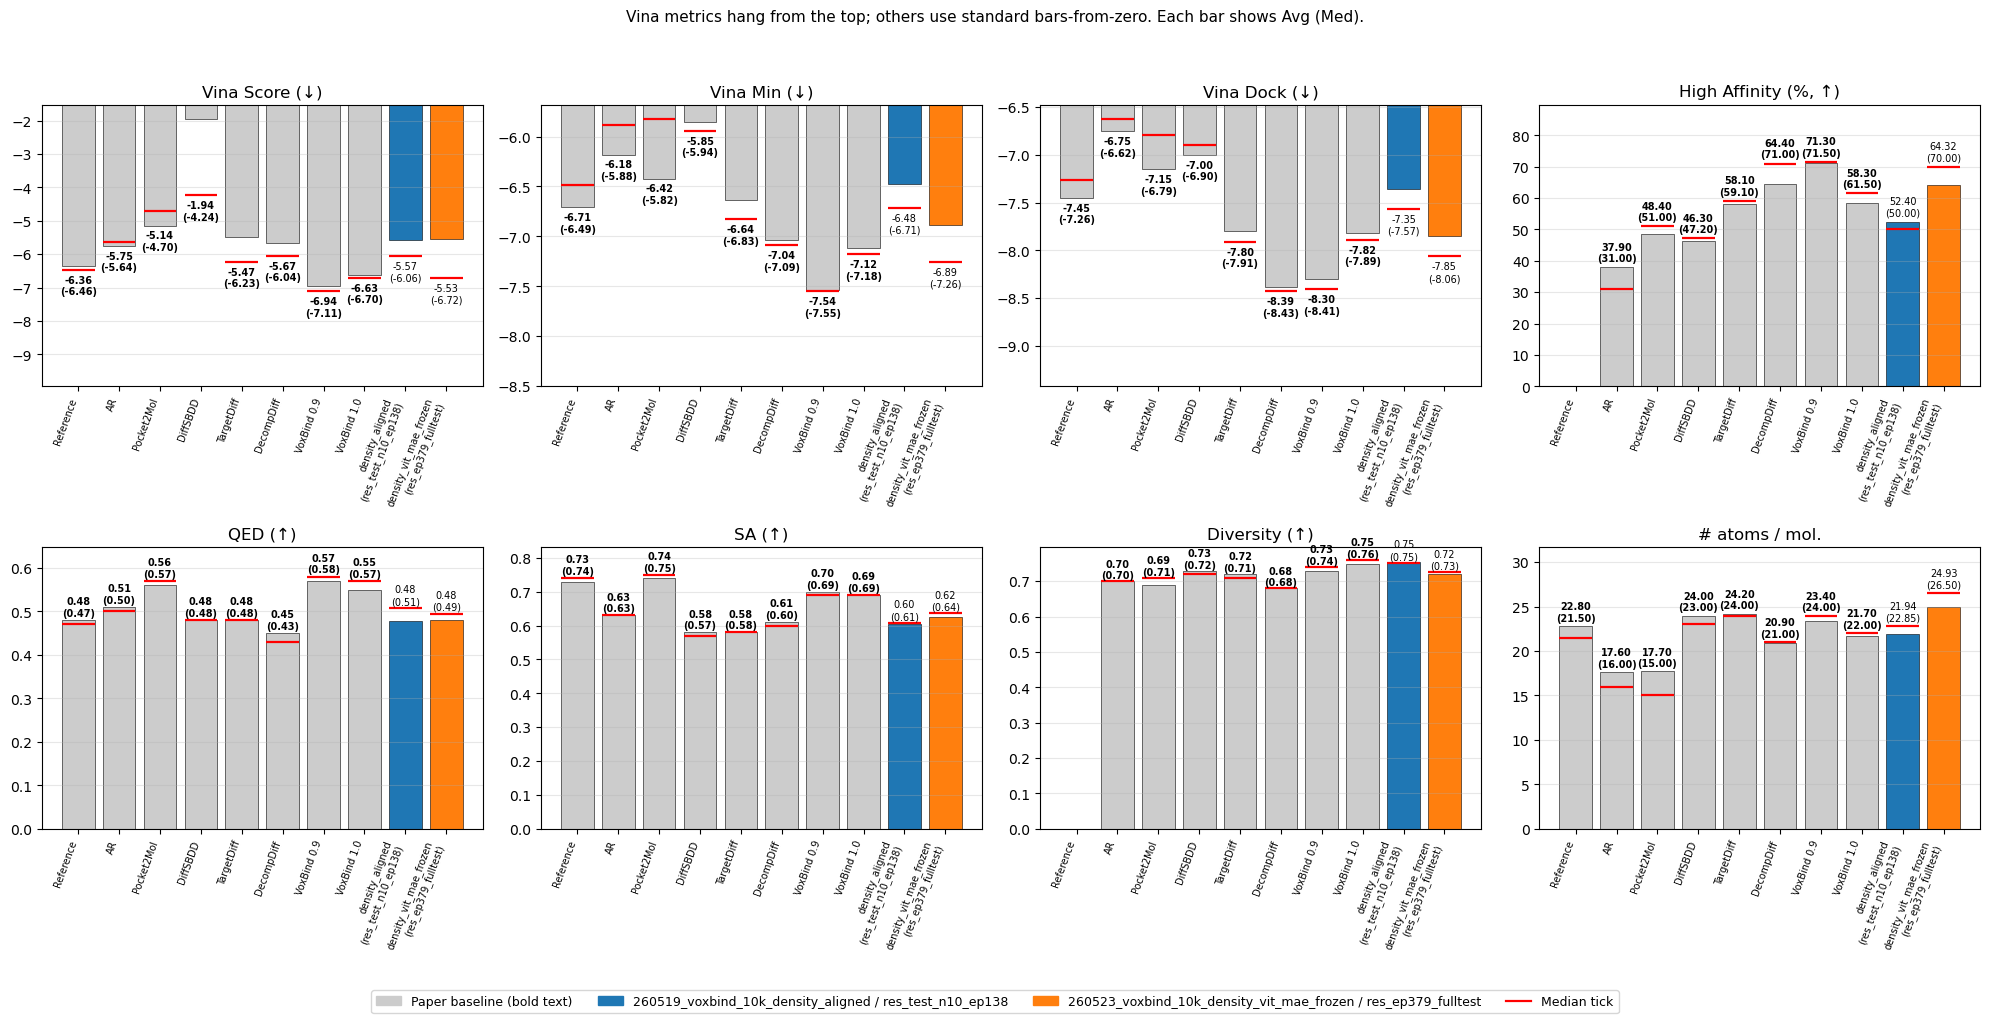

In [4]:
# Section 6c - Bar plot: paper baselines + selected runs from our experiments.
# Vina metrics use HANGING bars (bar tip drops from the top of the y-range
# down to the Avg value) so the visual matches a "lower is better, more
# negative = more bar" reading. Non-Vina metrics use the standard bars-from-
# zero layout. A red horizontal tick marks the Med, and every bar has its
# Avg (Med) printed next to its tip so the paper-figure values are readable.
#
# `SELECTED_FOR_PLOT` chooses which (experiment, run) pairs become *colored*
# bars; everything else under EXPS is hidden so the figure stays focused on
# the runs being compared against the paper baselines. Baselines (gray) are
# always shown.
import matplotlib.pyplot as plt

SELECTED_FOR_PLOT = [
    ("260519_voxbind_10k_density_aligned",        "res_test_n10_ep138"),
    ("260523_voxbind_10k_density_vit_mae_frozen", "res_ep379_fulltest"),
]


def _short_run_label(exp_name, run):
    """Compact bar label: strip the YYMMDD_ date prefix and shared
    'voxbind_10k_' chunk from the experiment name, then append the run name in
    parens. Keeps labels readable when rotated under bars."""
    head = exp_name.split("_", 1)[1] if "_" in exp_name else exp_name
    head = head.replace("voxbind_10k_", "")
    return f"{head}\n({run})"


# Collect plot rows in display order: baselines first, then our selected runs.
plot_rows = []
for name, vals in PAPER_BASELINES.items():
    row = {"label": name, "kind": "paper", "color_key": name}
    for metric, _, _ in PLOT_METRICS:
        avg, med = vals.get(metric, (None, None))
        row[f"{metric}_avg"] = float("nan") if avg is None else float(avg)
        row[f"{metric}_med"] = float("nan") if med is None else float(med)
    plot_rows.append(row)

for exp_name, run in SELECTED_FOR_PLOT:
    if run not in list_runs(EXPS_ROOT / exp_name):
        print(f"skip: {exp_name} / {run} - run directory not found")
        continue
    df = per_target_table(exp_name, run)
    if df.empty:
        print(f"skip: {exp_name} / {run} - no per-target rows")
        continue
    agg = experiment_aggregate_avg_med(df)
    row = {"label": _short_run_label(exp_name, run),
           "kind": "ours", "color_key": (exp_name, run)}
    for metric, _, _ in PLOT_METRICS:
        row[f"{metric}_avg"] = agg[f"{metric}_avg"]
        row[f"{metric}_med"] = agg[f"{metric}_med"]
    plot_rows.append(row)

plot_df = pd.DataFrame(plot_rows)

# One matplotlib color per selected (experiment, run); baselines all gray.
_exp_palette = {pair: f"C{i}" for i, pair in enumerate(SELECTED_FOR_PLOT)}
bar_colors = ["#cccccc" if k == "paper" else _exp_palette[ck]
              for k, ck in zip(plot_df["kind"], plot_df["color_key"])]

n_metrics = len(PLOT_METRICS)
n_cols = 4
n_rows = (n_metrics + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(n_cols * 5.0, n_rows * 5.0))
axes = np.atleast_1d(axes).flatten()

x = np.arange(len(plot_df))
for ax, (metric, label, lb) in zip(axes, PLOT_METRICS):
    avg = plot_df[f"{metric}_avg"].values.astype(float)
    med = plot_df[f"{metric}_med"].values.astype(float)
    finite = np.concatenate([avg[~np.isnan(avg)], med[~np.isnan(med)]])
    if finite.size == 0:
        ax.set_visible(False)
        continue
    vmax, vmin = float(finite.max()), float(finite.min())
    span = max(vmax - vmin, abs(vmax) * 0.1 + 1e-6)

    is_vina = metric.startswith("vina_")
    if is_vina:
        # Hanging bars: bottom anchored at the top of the y-range,
        # bar drops down to the Avg value.
        top = vmax + 0.08 * span
        floor = vmin - 0.55 * span
        heights = np.where(np.isnan(avg), 0.0, avg - top)
        ax.bar(x, heights, bottom=top, color=bar_colors,
               edgecolor="black", linewidth=0.4)
        ax.set_ylim(floor, top)
    else:
        # Standard bars from 0 up to the Avg value.
        ymin = min(0.0, vmin - 0.05 * span)
        ymax = vmax + 0.45 * span        # room above for value labels
        heights = np.where(np.isnan(avg), 0.0, avg)
        ax.bar(x, heights, bottom=0.0, color=bar_colors,
               edgecolor="black", linewidth=0.4)
        ax.set_ylim(ymin, ymax)

    # Median tick across each bar (same for both layouts).
    for xi, m in zip(x, med):
        if not np.isnan(m):
            ax.hlines(m, xi - 0.4, xi + 0.4, colors="red", linewidth=1.6)

    # Avg / Med value labels.
    # - Vina (hanging): place text BELOW the bar tip, anchored at the lower of
    #   avg/med so it never overlaps the median tick.
    # - Others (standard): place text ABOVE the bar tip, anchored at the
    #   higher of avg/med for the same reason.
    text_off = 0.03 * span
    for xi, a, m, kind in zip(x, avg, med, plot_df["kind"]):
        if np.isnan(a) and np.isnan(m):
            continue
        a_str = "—" if np.isnan(a) else f"{a:.2f}"
        m_str = "—" if np.isnan(m) else f"{m:.2f}"
        weight = "bold" if kind == "paper" else "normal"
        if is_vina:
            anchor = float(np.nanmin([a, m]))
            ax.text(xi, anchor - text_off,
                    f"{a_str}\n({m_str})",
                    ha="center", va="top", fontsize=7,
                    color="black", fontweight=weight)
        else:
            anchor = float(np.nanmax([a, m]))
            ax.text(xi, anchor + text_off,
                    f"{a_str}\n({m_str})",
                    ha="center", va="bottom", fontsize=7,
                    color="black", fontweight=weight)

    ax.set_title(label, fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["label"].tolist(),
                       rotation=70, ha="right", fontsize=7)
    ax.grid(axis="y", alpha=0.3)

# Hide unused axes.
for ax in axes[n_metrics:]:
    ax.set_visible(False)

# Legend: gray swatch for paper, one swatch per selected (experiment, run),
# red Median tick.
legend_handles = [plt.Rectangle((0, 0), 1, 1, color="#cccccc",
                                 label="Paper baseline (bold text)")]
for exp_name, run in SELECTED_FOR_PLOT:
    legend_handles.append(
        plt.Rectangle((0, 0), 1, 1, color=_exp_palette[(exp_name, run)],
                       label=f"{exp_name} / {run}")
    )
legend_handles.append(
    plt.Line2D([0], [0], color="red", linewidth=1.6, label="Median tick")
)
fig.legend(handles=legend_handles, loc="lower center",
           ncol=min(len(legend_handles), 4), fontsize=9,
           bbox_to_anchor=(0.5, -0.01))

fig.suptitle("Vina metrics hang from the top; others use standard bars-from-zero. "
             "Each bar shows Avg (Med).",
             fontsize=11, y=1.0)
plt.tight_layout(rect=[0, 0.04, 1, 0.97])
plt.show()


## Results

Set `SELECTED` below to an `idx` from the table in section 1 (or to an
experiment-name string), then run the remaining cells.

### Experiments - sample directories

In [5]:
# ======================================================================
#  vvv  SELECT THE EXPERIMENT  vvv   - idx from section 1, or its name
SELECTED = 0
# ======================================================================

if not EXPS:
    raise RuntimeError("No experiments to select - see section 1.")
if isinstance(SELECTED, int):
    sel_exp = EXPS[SELECTED]
elif SELECTED in EXPS:
    sel_exp = SELECTED
else:
    raise ValueError(f"SELECTED={SELECTED!r} is not a valid idx or name; "
                     f"choose from {EXPS}")

sel_runs = list_runs(EXPS_ROOT / sel_exp)
print(f"selected experiment : {sel_exp}")
print(f"sampling runs       : {sel_runs}")

agg_rows = []
for run in sel_runs:
    df = per_target_table(sel_exp, run)
    if df.empty:
        continue
    agg_rows.append({"run": run, **experiment_aggregate(df)})

if agg_rows:
    agg_df = pd.DataFrame(agg_rows).set_index("run")
    print(f"{sel_exp} - aggregate metrics (mean over targets)")
    show(agg_df)
    if agg_df[VINA_COLS].isna().all().all():
        print("  docking metrics (vina_*): not computed for this experiment")
else:
    print(f"{sel_exp}: no targets to aggregate.")

selected experiment : 260519_voxbind_10k_density_aligned
sampling runs       : ['res_test_n10', 'res_test_n10_ep138']
260519_voxbind_10k_density_aligned - aggregate metrics (mean over targets)


,n_targets,evaluated,validity,uniqueness,diversity,qed,sa,logp,lipinski,clash_free,n_clashes,high_affinity,sim,vina_score,vina_min,vina_dock,vina_n_failed
run,,,,,,,,,,,,,,,,,
res_test_n10,8,8,0.988,1.0,0.701,0.459,0.580,1.190,4.653,0.988,0.012,0.457,0.254,-6.319,-6.902,-8.026,0
res_test_n10_ep138,50,50,1.000,1.0,0.754,0.478,0.603,1.364,4.489,0.996,0.004,0.524,0.222,-5.566,-6.477,-7.354,0


### Experiments - over runs

In [6]:
# Section 3 - per-target metrics for every run of the selected experiment.
def _color_targets_vs_reference(df, exp_name, run):
    """Per-target table CSS: shade each metric green/red when the target's
    generated molecules beat / fall short of that target's own reference
    ligand (from its metrics.json). qed/sa/lipinski are higher-is-better,
    vina_* lower-is-better; columns with no reference value or no defined
    direction (logp, the count columns) stay uncoloured.
    """
    higher = ["qed", "sa", "lipinski"]               # higher is better
    lower = ["vina_score", "vina_min", "vina_dock"]  # lower is better
    green = "background-color: #d8f0d8;"
    red = "background-color: #f5d8d8;"
    css = pd.DataFrame("", index=df.index, columns=df.columns)
    for tname in df.index:
        tdir = EXPS_ROOT / exp_name / "samples" / run / tname
        ref = target_reference(load_metrics(tdir))
        if not ref:
            continue
        for col in higher + lower:
            if col not in df.columns or col not in ref:
                continue
            val = df.at[tname, col]
            if pd.isna(val):
                continue
            better = val > ref[col] if col in higher else val < ref[col]
            css.at[tname, col] = green if better else red
    return css


for run in sel_runs:
    df = per_target_table(sel_exp, run)
    print(f"\n{'='*72}\n{sel_exp}  /  {run}\n{'='*72}")
    if df.empty:
        print("  (no target directories)")
        continue
    df = df.set_index("target")
    styled = (df.style
              .apply(_color_targets_vs_reference, exp_name=sel_exp, run=run,
                     axis=None)
              .format(precision=3, na_rep="NaN"))
    show(styled)
    print("  green / red cell = target metric better / worse than its reference ligand")
    n_no_dock = int(df[VINA_COLS].isna().all(axis=1).sum())
    if n_no_dock == len(df):
        print("  docking (vina_*): not computed for any target in this run")
    elif n_no_dock:
        print(f"  docking (vina_*): not computed for {n_no_dock}/{len(df)} targets")

if not sel_runs:
    print(f"{sel_exp}: no sampling runs.")


260519_voxbind_10k_density_aligned  /  res_test_n10


,status,computed_at,n_total,n_valid,validity,uniqueness,diversity,qed,sa,logp,lipinski,clash_free,n_clashes,atoms,sim,vina_score,vina_min,vina_dock,vina_n_failed,high_affinity
target,,,,,,,,,,,,,,,,,,,,
target_02,fresh,2026-05-20 11:31,10,10,1.000,1.000,0.584,0.503,0.504,1.679,4.200,1.000,0.000,30.100,0.419,-7.288,-7.833,-8.632,0,0.900
target_03,fresh,2026-05-20 11:31,10,10,1.000,1.000,0.891,0.470,0.670,0.096,5.000,1.000,0.000,13.000,0.095,-3.473,-3.796,-5.019,0,0.000
target_04,fresh,2026-05-20 11:32,10,10,1.000,1.000,0.386,0.537,0.552,2.759,4.800,1.000,0.000,31.800,0.134,-13.296,-13.937,-14.391,0,1.000
target_05,fresh,2026-05-20 11:32,10,10,1.000,1.000,0.874,0.448,0.679,0.623,4.700,1.000,0.000,18.500,0.183,-1.293,-2.427,-4.392,0,0.100
target_07,fresh,2026-05-20 11:33,10,10,1.000,1.000,0.657,0.473,0.565,1.140,4.500,0.900,0.100,27.500,0.427,-6.749,-7.098,-8.259,0,0.200
target_08,fresh,2026-05-20 11:33,10,10,1.000,1.000,0.760,0.533,0.589,1.046,5.000,1.000,0.000,22.600,0.103,-6.255,-6.694,-7.764,0,0.900
target_09,fresh,2026-05-20 12:44,10,9,0.900,1.000,0.697,0.326,0.488,2.078,4.222,1.000,0.000,28.444,0.331,NaN,NaN,NaN,0,NaN
target_10,fresh,2026-05-20 12:45,10,10,1.000,1.000,0.758,0.379,0.597,0.098,4.800,1.000,0.000,22.400,0.343,-5.881,-6.530,-7.726,0,0.100


  green / red cell = target metric better / worse than its reference ligand
  docking (vina_*): not computed for 1/8 targets

260519_voxbind_10k_density_aligned  /  res_test_n10_ep138


,status,computed_at,n_total,n_valid,validity,uniqueness,diversity,qed,sa,logp,lipinski,clash_free,n_clashes,atoms,sim,vina_score,vina_min,vina_dock,vina_n_failed,high_affinity
target,,,,,,,,,,,,,,,,,,,,
target_02,fresh,2026-05-21 12:23,9,9,1.000,1.000,0.509,0.592,0.531,2.636,4.667,1.000,0.000,29.444,0.457,-6.993,-7.550,-8.199,0,1.000
target_03,fresh,2026-05-21 12:23,10,10,1.000,1.000,0.873,0.453,0.632,0.977,4.500,1.000,0.000,17.700,0.128,-3.830,-4.119,-5.367,0,0.100
target_04,fresh,2026-05-21 12:23,10,10,1.000,1.000,0.454,0.491,0.579,3.689,4.400,1.000,0.000,33.200,0.141,-12.475,-13.014,-13.441,0,1.000
target_05,fresh,2026-05-21 12:23,10,10,1.000,1.000,0.826,0.514,0.614,2.557,4.900,1.000,0.000,22.300,0.242,-2.819,-3.262,-5.137,0,0.200
target_07,fresh,2026-05-21 12:23,10,10,1.000,1.000,0.667,0.495,0.603,2.215,4.700,0.900,0.100,27.600,0.423,-6.964,-7.586,-8.723,0,0.200
target_08,fresh,2026-05-21 12:23,10,10,1.000,1.000,0.705,0.540,0.646,1.829,4.800,1.000,0.000,24.300,0.121,-7.655,-8.156,-8.775,0,1.000
target_09,fresh,2026-05-21 12:23,10,10,1.000,1.000,0.729,0.425,0.538,3.051,4.400,1.000,0.000,28.100,0.324,-4.521,-6.192,-6.969,0,0.900
target_10,fresh,2026-05-21 12:23,10,10,1.000,1.000,0.718,0.489,0.627,1.865,4.800,1.000,0.000,25.500,0.383,-6.644,-7.394,-8.415,0,0.200
target_11,fresh,2026-05-21 12:23,10,10,1.000,1.000,0.566,0.410,0.510,0.740,4.000,1.000,0.000,28.500,0.450,-8.562,-8.966,-9.618,0,0.600


  green / red cell = target metric better / worse than its reference ligand


### Experiments - per sample

Every generated molecule for a single target. Leave `RUN` / `SELECTED_TARGET`
as `None` to auto-pick the evaluated target with the most samples, or set them
to an index or name to inspect a specific one.

In [7]:
# Section 5 - per-sample metrics for one target.
RUN = None              # None -> auto | index into sel_runs | run-name string
SELECTED_TARGET = None  # None -> auto | index into the run's targets | target name

if not sel_runs:
    print(f"{sel_exp}: no sampling runs.")
else:
    if RUN is None and SELECTED_TARGET is None:
        run, tname = first_evaluated(sel_exp)
    else:
        run = sel_runs[RUN] if isinstance(RUN, int) else (RUN or sel_runs[0])
        tnames = [t.name for t in list_targets(sel_exp, run)]
        if SELECTED_TARGET is None:
            tname = tnames[0] if tnames else None
        elif isinstance(SELECTED_TARGET, int):
            tname = tnames[SELECTED_TARGET]
        else:
            tname = SELECTED_TARGET

    if run is None or tname is None:
        print(f"{sel_exp}: no samples to display.")
    else:
        tdir = EXPS_ROOT / sel_exp / "samples" / run / tname
        df = per_sample_table(sel_exp, run, tname)
        print(f"{sel_exp}  /  {run}  /  {tname}   "
              f"(status: {metrics_status(tdir)})")
        if df.empty:
            print("  no metrics.json - this target has not been evaluated yet")
        else:
            show(df.set_index("idx"))
            if df[VINA_COLS].isna().all().all():
                print("  docking (vina_*): not computed for these samples")

260519_voxbind_10k_density_aligned  /  res_test_n10  /  target_02   (status: fresh)


,smiles,n_atoms,qed,sa,logp,lipinski,n_contacts,n_clashes,min_dist,sim_to_ref,vina_score,vina_min,vina_dock,vina_status,vina_err
idx,,,,,,,,,,,,,,,
0,N=C1[C@H]2CC=CCN2C2CN(c3ccccc3)CN=C2N1CC1CCCC1,27,0.838,0.66,3.345,5,16,0,3.300,0.383,-7.093,-8.117,-8.603,OK,
1,CNC[C@H]1C=C2C3=C(C=C4N2NC(=N)N2C(=N)C[C@H](C)[C@H](CO)N42)CC=NC3=C1O,30,0.405,0.47,0.767,4,22,0,2.840,0.522,-8.237,-9.073,-9.206,OK,
2,Cc1cc(CC(=O)NNO)cc2c1=C1C=CCC(=C(O)C[C@H](C)O[C@@H](O)C[C@H](N)N=2)C1,31,0.377,0.43,0.282,4,27,0,2.728,0.407,-9.177,-9.699,-9.925,OK,
3,N=CCC1=NN2CC(C3=CCC(O)=C(OO)C3)=NN(C3C=C(C[C@H](O)OC(=O)O)CC[C@@H]3O)[C@@H]2CN1,36,0.062,0.45,1.075,2,26,0,2.690,0.468,-5.762,-7.185,-8.267,OK,
4,COCN1[C@H]2CO[C@H](OC)C3C=C4CC=CC5=NCC6C7=C(C(=C4N56)[C@H]32)[C@@]1(C)C[C@H]1CCC[C@@H]1[C@H](C)O7,37,0.578,0.44,3.998,4,23,0,2.846,0.526,-9.075,-9.736,-10.319,OK,
5,Cc1cc2c3c4c1=NC(=O)[C@H](C[C@H]1OCC(=CO)[C@@H](N)O1)C4=N[C@@H](C)[C@H]3C=CN=2,29,0.715,0.47,0.682,5,25,0,2.686,0.498,-7.452,-8.696,-8.999,OK,
6,CCN1CC(C[C@@H](C)NC)=C2[C@@H]3C(=NC4=C5c6c(ncnc6C(N)C4=O)CON53)C(C)C[C@@H]21,33,0.663,0.49,1.337,5,21,0,2.967,0.563,-7.992,-8.331,-9.165,OK,
7,COCC=C1C(=C2CC=NCC2)CC(C)=C1C(=N)CO[C@@H]1C=CC=CC1,26,0.722,0.58,4.362,5,24,0,2.948,0.276,-5.919,-5.685,-7.349,OK,
8,CC=C1C=CC2=C3C(=C(C[C@H](O)O[C@H]4CC[C@H](C)[C@@H](O)C4)[C@H](C)C[C@@H]13)C1=NNCC[C@@H]1C2=N,33,0.485,0.46,4.025,5,26,0,2.905,0.384,-8.194,-7.465,-9.362,OK,
